<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/AI_Based_Malware_%26_Phishing_System_Using_ML_Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI-Based Malware & Phishing System Using ML**

**Large DataSet Generation**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 10000

df = pd.DataFrame({

    "URLs": np.random.randint(0, 10, rows),

    "Attachments": np.random.randint(0, 2, rows),

    "Urgent_Words": np.random.randint(0, 2, rows),

    "Sender_Reputation": np.random.randint(1, 11, rows),

    "Misspelled_Words": np.random.randint(0, 15, rows),

    "External_Links": np.random.randint(0, 20, rows),

    "Email_Length": np.random.randint(50, 2000, rows),

    "Suspicious_Domain": np.random.randint(0, 2, rows),

    "Login_Request": np.random.randint(0, 2, rows)
})

df.head()

,URLs,Attachments,Urgent_Words,Sender_Reputation,Misspelled_Words,External_Links,Email_Length,Suspicious_Domain,Login_Request
0,6,0,0,3,4,17,429,0,0
1,3,1,0,3,10,13,1668,1,0
2,7,0,1,6,7,8,873,0,0
3,4,0,0,1,1,8,112,1,1
4,6,1,1,7,2,11,181,0,1


**Generate Threat Labels**

In [ ]:
df["Threat"] = (
    (df["URLs"] > 5) |
    (df["Urgent_Words"] == 1) |
    (df["Sender_Reputation"] < 4) |
    (df["Suspicious_Domain"] == 1) |
    (df["Login_Request"] == 1)
).astype(int)

df.head()

,URLs,Attachments,Urgent_Words,Sender_Reputation,Misspelled_Words,External_Links,Email_Length,Suspicious_Domain,Login_Request,Threat
0,6,0,0,3,4,17,429,0,0,1
1,3,1,0,3,10,13,1668,1,0,1
2,7,0,1,6,7,8,873,0,0,1
3,4,0,0,1,1,8,112,1,1,1
4,6,1,1,7,2,11,181,0,1,1


**Exploratory Data Analysis**

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   URLs               10000 non-null  int64
 1   Attachments        10000 non-null  int64
 2   Urgent_Words       10000 non-null  int64
 3   Sender_Reputation  10000 non-null  int64
 4   Misspelled_Words   10000 non-null  int64
 5   External_Links     10000 non-null  int64
 6   Email_Length       10000 non-null  int64
 7   Suspicious_Domain  10000 non-null  int64
 8   Login_Request      10000 non-null  int64
 9   Threat             10000 non-null  int64
dtypes: int64(10)
memory usage: 781.4 KB


,URLs,Attachments,Urgent_Words,Sender_Reputation,Misspelled_Words,External_Links,Email_Length,Suspicious_Domain,Login_Request,Threat
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.497200,0.503300,0.509900,5.520600,7.061500,9.414300,1022.573500,0.500500,0.507300,0.949300
std,2.893964,0.500014,0.499927,2.842355,4.278265,5.769071,564.579069,0.500025,0.499972,0.219395
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,3.000000,3.000000,4.000000,529.750000,0.000000,0.000000,1.000000
50%,5.000000,1.000000,1.000000,5.000000,7.000000,9.000000,1031.000000,1.000000,1.000000,1.000000
75%,7.000000,1.000000,1.000000,8.000000,11.000000,14.000000,1507.000000,1.000000,1.000000,1.000000
max,9.000000,1.000000,1.000000,10.000000,14.000000,19.000000,1999.000000,1.000000,1.000000,1.000000


**Threat Distribution**

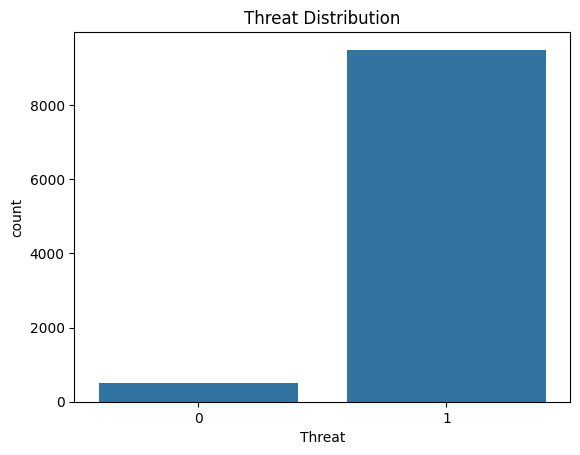

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Threat", data=df)
plt.title("Threat Distribution")
plt.show()

**Correlation Heatmap**

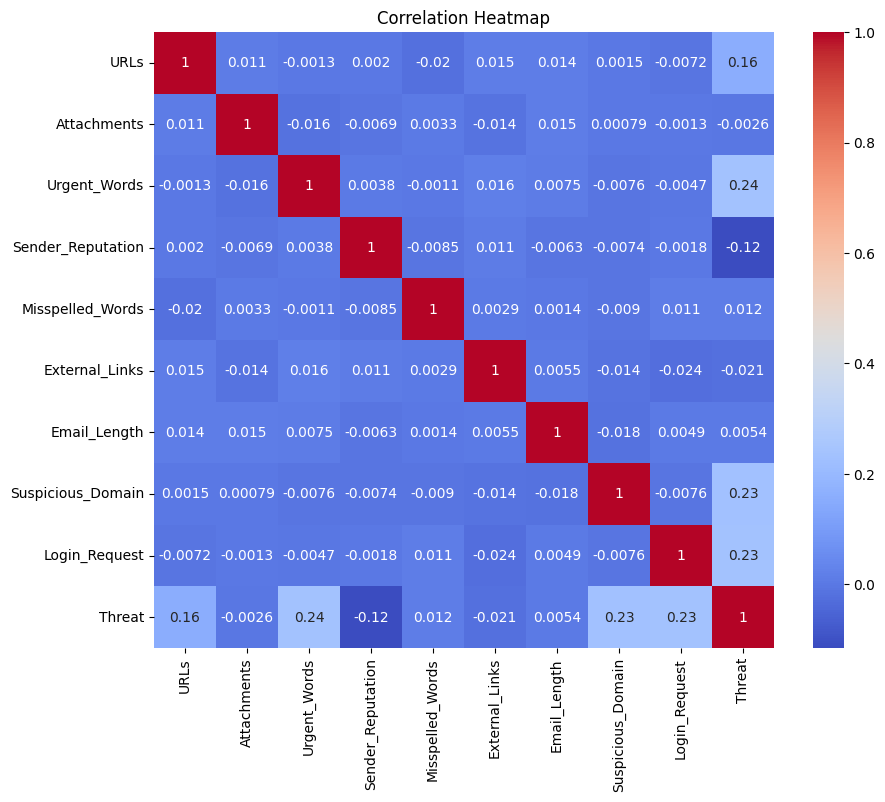

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
  )
plt.title("Correlation Heatmap")
plt.show()

**feature Engineering**

In [ ]:
df["Risk_Score"] = (
    df["URLs"]  +
    df["External_Links"] +
    df["Misspelled_Words"]
)

df["Trust_Score"] = (
    df["Sender_Reputation"] -
    df["Urgent_Words"]*3
)




**Train_Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Threat", axis=1)
y = df["Threat"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Model 1 Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**Model 2 : DecisionTreeClassifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

**Model 3 : Random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**Model Evalution**

In [ ]:
from sklearn.metrics import accuracy_score

print(
    "Logistic Regression:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Decision Tree:",
    accuracy_score(y_test, dt_pred)
)

print(
    "Random Forest:",
    accuracy_score(y_test, rf_pred)
)

Logistic Regression: 0.9845
Decision Tree: 1.0
Random Forest: 1.0


**Advanced Evalution**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00      1903

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



**Feature Importance**

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,Suspicious_Domain,0.224878
0,URLs,0.201750
8,Login_Request,0.197021
2,Urgent_Words,0.141898
10,Trust_Score,0.096548
3,Sender_Reputation,0.068011
9,Risk_Score,0.022876
6,Email_Length,0.017288
5,External_Links,0.014527
4,Misspelled_Words,0.012974


**Visualization**

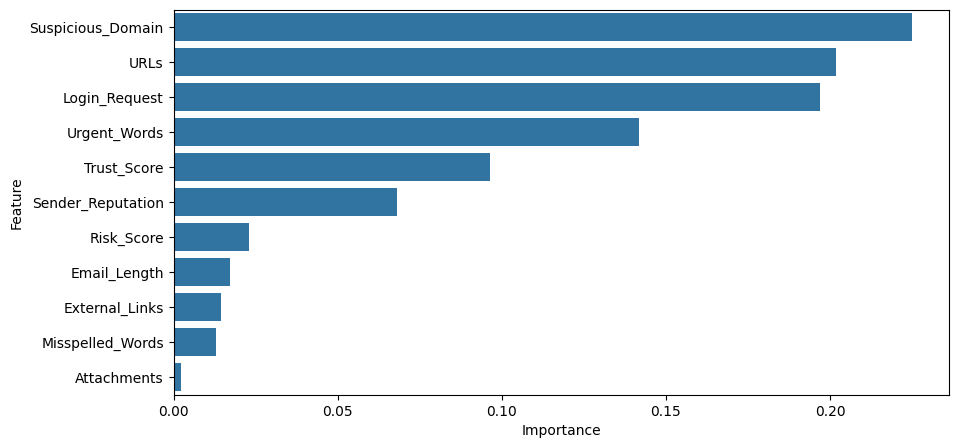

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()

**Predict New  Email**

In [ ]:
new_email = pd.DataFrame({
    "URLs":[8],
    "Attachments":[1],
    "Urgent_Words":[1],
    "Sender_Reputation":[2],
    "Misspelled_Words":[10],
    "External_Links":[12],
    "Email_Length":[500],
    "Suspicious_Domain":[1],
    "Login_Request":[1],
    "Risk_Score":[30],
    "Trust_Score":[-1]

})
prediction = rf.predict(new_email)

if prediction[0] == 1:
    print("Threat Detected")
else:
    print("Safe Email")

Threat Detected


**Threat Alert System**

In [ ]:
probability = rf.predict_proba(new_email)

risk = probability[0][1]

if risk > 0.8:
    print("HIGH RISK ALERT")
elif risk > 0.5:
    print("MEDIUM RISK ALERT")
else:
    print("LOW RISK")

HIGH RISK ALERT


Activity 1: Threat Pattern Analysis Identify:
Top 5 Phishing indicators:
1. Suspicious Domain
2. URL
3. Urgent Words
4. Login Requests
5. Trust Score

**Most important features:**
1. Suspicious domains
2. URLs